# Proyecto Sprint 14: Proyecto final (Entrega del proyecto)

# Enlace a la presentación

https://www.canva.com/design/DAGbqkMIthc/Lo2XB2VoNPnevu4DXXRHAg/view?utm_content=DAGbqkMIthc&utm_campaign=designshare&utm_medium=link2&utm_source=uniquelinks&utlId=hebca454080

# Tabla de contenidos <a id='back'></a>

* [Descripción del proyecto](#Proyecto)
    * [Introducción](#Introduccion)
    * [Objetivo Principal](#Objetivo)
    * [Diccionario de datos](#Diccionario)
* [Etapa 1. Descripción de los datos](#Descripcion)
* [Etapa 2. Preprocesamiento de datos](#Preprocesamiento)
* [Etapa 3. Análisis exploratorio de datos (EDA)](#Analisis)
* [Etapa 4. Planteamiento y Prueba de Hipótesis ](#hipotesis)
* [Etapa 5. Conclusiones y recomendaciones](#Conclusion)

# Descripción del proyecto<a id='Proyecto'></a>

# Introducción<a id='Introduccion'></a>

El presente proyecto busca identificar operadores ineficaces en el servicio de telefonía virtual CallMeMaybe. Para lograrlo, se emplea un enfoque basado en análisis de datos que evalúa el desempeño de los operadores utilizando métricas clave. Se espera que estas métricas permitan detectar patrones de ineficiencia en la gestión de las llamadas y comprender mejor las áreas críticas que afectan la calidad del servicio brindado a los clientes.

El análisis también busca correlaciones entre estas métricas y otros factores relevantes. Este enfoque integral no solo facilitara la identificación de operadores con bajo rendimiento, sino que también ofrecerá información clave para diseñar estrategias de mejora que optimicen la experiencia del cliente y la eficiencia operativa.

# Objetivo Principal

Identificar operadores ineficaces mediante el análisis de métricas clave de desempeño, para proporcionar información que permita a los supervisores implementar acciones correctivas y mejorar la gestión del servicio al cliente.

# Diccionario de datos<a id='Diccionario'></a>

Estructura `telecom_dataset_us.csv`:

- `user_id`: ID de la cuenta de cliente
- `date`: fecha en la que se recuperaron las estadísticas
- `direction`: "dirección" de llamada (`out` para saliente, `in` para entrante)
- `internal`: si la llamada fue interna (entre los operadores de un cliente o clienta)
- `operator_id`: identificador del operador
- `is_missed_call`: si fue una llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración de la llamada (sin incluir el tiempo de espera)
- `total_call_duration`: duración de la llamada (incluido el tiempo de espera)

 

Estructura `telecom_clients_us.csv`:

- `user_id`: ID de usuario/a
- `tariff_plan`: tarifa actual de la clientela
- `date_start`: fecha de registro de la clientela

[Volver a Contenidos](#back)

# Descripción de los datos<a id='Descripcion'></a>

In [1]:
#Se importar todas las librerias necesarias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import pearsonr, spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import f_oneway

In [2]:
#Se cargan los datos
#Se elige mantener los DF originales, y aplicar los cambios posteriores en copias de cada DF

data_raw = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients_raw = pd.read_csv('/datasets/telecom_clients_us.csv')

In [3]:
#Se muestra la información general de cada DataFrame

print('Información de data:')
data_raw.info()
print('\n')
print('Información de clients:')
clients_raw.info()

Información de data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


Información de clients:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int6

In [4]:
#Se calcula la cantidad de duplicados del DataFrame

print('Duplicados en los datos de data:', data_raw.duplicated().sum())
print('Duplicados en los datos de clients:', clients_raw.duplicated().sum())

Duplicados en los datos de data: 4900
Duplicados en los datos de clients: 0


In [5]:
#Se muestran las primeras 5 lineas de cada DataFrame

print('Primeras 5 lineas de "data"')
print(data_raw.head())
print('\n')
print('Primeras 5 lineas de "clients"')
print(clients_raw.head())

Primeras 5 lineas de "data"
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  


Primeras 5 lineas de "clients"
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901      

No se requiere ninguna condicion adicional necesaria para la lectura de los datos.

Con el fin de optimizar el manejo de los datos se determinaron ciertos cambios aplicables en la siguiente etapa:

**DataFrame data:**
* Analizar a fondo los valores nulos detectados en la columna operator_id e internal.
* Analizar los valores duplicados detectados en el DF.
* Columna date cambiar al tipo fecha y hora.
* Columna operator_id cambiar al tipo int.

**DataFrame clients:**
* Columna tariff_plan cambiar al tipo categorico.
* Columna date_start cambiar al tipo fecha.

[Volver a Contenidos](#back)

# Preprocesamiento de los datos<a id='Preprocesamiento'></a>

In [6]:
#Se crea una copia independiente de cada DataFrame

data = data_raw.copy()
clients = clients_raw.copy()

In [7]:
#Se decide eliminar las filas duplicadas para evitar redundancias que puedan sesgar los análisis

data = data.drop_duplicates()

print(f"Número de duplicados despues de la eliminación: {data.duplicated().sum()}")

Número de duplicados despues de la eliminación: 0


In [8]:
#Se analizan los datos estadísticos y características de las filas con operator_id nulo

df_operator_nulls = data[data['operator_id'].isnull()]

print(df_operator_nulls.describe(include='all', percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99]))

              user_id                       date direction internal  \
count     7456.000000                       7456      7456     7401   
unique            NaN                        119         2        2   
top               NaN  2019-10-28 00:00:00+03:00        in    False   
freq              NaN                        128      7270     7078   
mean    167259.123793                        NaN       NaN      NaN   
std        586.842979                        NaN       NaN      NaN   
min     166377.000000                        NaN       NaN      NaN   
10%     166533.000000                        NaN       NaN      NaN   
25%     166782.000000                        NaN       NaN      NaN   
50%     167125.000000                        NaN       NaN      NaN   
75%     167727.000000                        NaN       NaN      NaN   
90%     168154.500000                        NaN       NaN      NaN   
95%     168275.000000                        NaN       NaN      NaN   
98%   

In [9]:
#Se decide mantener las filas con datos nulos en operator_id

data['operator_id'] = data['operator_id'].fillna(0)

print(f"Cantidad de valores nulos despues de la eliminación: {data['operator_id'].isnull().sum()}")

Cantidad de valores nulos despues de la eliminación: 0


In [10]:
#Se cuenta la cantidad de valores nulos en internal

print(f"Cantidad de valores nulos en internal: {data['internal'].isnull().sum()}")

Cantidad de valores nulos en internal: 110


In [11]:
#Se decide eliminar las filas con datos nulos en internal al representar un número tan bajo de datos

# Eliminar filas con internal nulo
data = data.dropna(subset=['internal'])

print(f"Cantidad de valores nulos en internal despues de la eliminación: {data['internal'].isnull().sum()}")

Cantidad de valores nulos en internal despues de la eliminación: 0


In [12]:
#Se decide eliminar la zona horaria de la columna date en data, pues no aporta información relevante
data['date'] = pd.to_datetime(data['date'])
data['date'] = data['date'].dt.tz_localize(None)

#Se cambia al tipo entero la columna operator_id
data['operator_id'] = data['operator_id'].astype('int')

#Se cambia al tipo datetime la columna date_start
clients['date_start'] = pd.to_datetime(clients['date_start'])

#Se cambia al tipo categorico la columna tariff_plan
clients['tariff_plan'] = clients['tariff_plan'].astype('category')

In [13]:
#Se muestra la información general de cada DataFrame

print('Información de data despues de aplicar los cambios:')
data.info()
print()
print('Información de clients despues de aplicar los cambios:')
clients.info()

Información de data despues de aplicar los cambios:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 48892 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              48892 non-null  int64         
 1   date                 48892 non-null  datetime64[ns]
 2   direction            48892 non-null  object        
 3   internal             48892 non-null  object        
 4   operator_id          48892 non-null  int64         
 5   is_missed_call       48892 non-null  bool          
 6   calls_count          48892 non-null  int64         
 7   call_duration        48892 non-null  int64         
 8   total_call_duration  48892 non-null  int64         
dtypes: bool(1), datetime64[ns](1), int64(5), object(2)
memory usage: 3.4+ MB

Información de clients despues de aplicar los cambios:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data co

In [14]:
#Se crea un unico DataFrame uniendo los existentes

telecom = data.merge(clients, on='user_id', how='left')

In [15]:
#Se crea una columna que almacena el tiempo de espera de cada llamada

telecom['waiting_time'] = telecom['total_call_duration'] - telecom['call_duration']

#Se convierten los segundos de cada columna a minutos

telecom['call_duration'] = telecom['call_duration'] / 60
telecom['total_call_duration'] = telecom['total_call_duration'] / 60
telecom['waiting_time'] = telecom['waiting_time'] / 60

print(telecom.head())

   user_id       date direction internal  operator_id  is_missed_call  \
0   166377 2019-08-04        in    False            0            True   
1   166377 2019-08-05       out     True       880022            True   
2   166377 2019-08-05       out     True       880020            True   
3   166377 2019-08-05       out     True       880020           False   
4   166377 2019-08-05       out    False       880022            True   

   calls_count  call_duration  total_call_duration tariff_plan date_start  \
0            2       0.000000             0.066667           B 2019-08-01   
1            3       0.000000             0.083333           B 2019-08-01   
2            1       0.000000             0.016667           B 2019-08-01   
3            1       0.166667             0.300000           B 2019-08-01   
4            3       0.000000             0.416667           B 2019-08-01   

   waiting_time  
0      0.066667  
1      0.083333  
2      0.016667  
3      0.133333  
4      0

In [16]:
#Se muestra la información general del nuevo DataFrame

telecom.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 48892 entries, 0 to 48891
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              48892 non-null  int64         
 1   date                 48892 non-null  datetime64[ns]
 2   direction            48892 non-null  object        
 3   internal             48892 non-null  object        
 4   operator_id          48892 non-null  int64         
 5   is_missed_call       48892 non-null  bool          
 6   calls_count          48892 non-null  int64         
 7   call_duration        48892 non-null  float64       
 8   total_call_duration  48892 non-null  float64       
 9   tariff_plan          48892 non-null  category      
 10  date_start           48892 non-null  datetime64[ns]
 11  waiting_time         48892 non-null  float64       
dtypes: bool(1), category(1), datetime64[ns](2), float64(3), int64(3), object(2)
memory usage

En la etapa de preprocesamiento de datos, se trabajó con copias independientes de cada DataFrame original para garantizar la integridad de los datos iniciales.

**Filas duplicadas:**
Se analizaron los datos contenidos en las filas duplicadas y, tras evaluar su impacto potencial en los análisis, se decidió eliminarlas para evitar redundancias que pudieran sesgar los resultados posteriores.

**Filas con valores nulos en operator_id:**
Se examinó la distribución y las características de las filas con valores nulos en la columna operator_id. Se determinó mantenerlas, pese a que el 98% de estas filas tenían una duración de llamada de 0, y el 98.5% (7343 de 7456 filas) correspondían a llamadas perdidas, tambien se encontró que el tiempo de espera de cada llamada era alto. Este patrón puede aportar información relevante para los propositos del analisis.

**Valores nulos en la columna internal:**
En la columna internal, se identificaron 110 valores nulos. Dado que representan una proporción insignificante del total de datos, se decidió eliminarlos.

**Cambios de tipo de dato:**
Se aplicaron las conversiones de tipo de dato previstas para esta etapa, asegurando la consistencia y el formato adecuado de las columnas.

**Nuevo DataFrame:**
Se crea un nuevo DataFrame combinando los DataFrames existentes ya procesados. A este nuevo DataFrame se le añade una columna denominada waiting_time que almacena el cálculo del tiempo de espera de cada llamada. Para facilitar la interpretación y dimensionar mejor la información, el tiempo de cada columna, originalmente en segundos, se convierte a minutos.

[Volver a Contenidos](#back)

# Análisis exploratorio de datos (EDA)<a id='Analisis'></a>

In [17]:
#Se revisan los valores estadisticos del DataFrame

print('Datos estadisticos de telecom:')
print(telecom.describe(include='all', percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98, 0.99]))

Datos estadisticos de telecom:
              user_id                 date direction internal    operator_id  \
count    48892.000000                48892     48892    48892   48892.000000   
unique            NaN                  119         2        2            NaN   
top               NaN  2019-11-25 00:00:00       out    False            NaN   
freq              NaN                 1107     28997    43239            NaN   
first             NaN  2019-08-02 00:00:00       NaN      NaN            NaN   
last              NaN  2019-11-28 00:00:00       NaN      NaN            NaN   
mean    167294.492841                  NaN       NaN      NaN  777779.541684   
std        598.675508                  NaN       NaN      NaN  329077.221961   
min     166377.000000                  NaN       NaN      NaN       0.000000   
10%     166520.000000                  NaN       NaN      NaN       0.000000   
25%     166782.000000                  NaN       NaN      NaN  890416.000000   
50%     1

In [18]:
#Se encuentra el percentile 99 para la columa de tiempo de espera
waiting_time_threshold = telecom['waiting_time'].quantile(0.99)

#Se filtran los operadores con valores superiores al percentil 99 de tiempo de espera
waiting_time_operators = telecom[telecom['waiting_time'] > waiting_time_threshold]['operator_id'].nunique()

#Se muestran los resultados
print(f"Operadores con más de {waiting_time_threshold:.2f} minutos de tiempo de espera: {waiting_time_operators}")

Operadores con más de 52.66 minutos de tiempo de espera: 34


Al analizar las estadísticas del DataFrame, se identifican valores atípicos que superan significativamente los promedios de las métricas principales. Por ejemplo:

**Cantidad de llamadas:** El promedio es de 16 llamadas por operador, mientras que el 1% superior registra hasta 165 llamadas, con un valor máximo sorprendente de 4817 llamadas. Es de destacar que el 50% de los operadores tiene un número de llamadas muy bajo apenas alcanzando 4 llamadas por operador.

**Duración de las llamadas:** El promedio es de 14 minutos, pero el 1% superior alcanza hasta 172 minutos, con un máximo de 2406 minutos. Es relevante señalar que el 50% de los operadores tiene llamadas que duran menos de un minuto.

**Duración total de las llamadas (incluido el tiempo de espera):** Tiene un promedio de 19 minutos, el 1% superior llega a 216 minutos, y el valor máximo asciende a 2769 minutos. Es importante señalar que el 50% de las llamadas alcanza los 3 minutos en total, lo cual implica un tiempo de espera superior.

**Tiempo de espera:** El promedio es de 5 minutos, mientras que el 1% superior llega a 52 minutos, con un máximo extremo de 774 minutos. Es igualmente destacable que el 50% de las llamadas tiene menos de un minuto de espera, pero el 75% de las llamadas ya alcanza 3 minutos de espera. Se detectan 34 operadores cuyo tiempo de espera por llamada supera el 99% de la cantidad de minutos de espera por llamada.

Estos valores atípicos resaltan la necesidad de un análisis más detallado para comprender sus causas y evaluar su impacto en la eficacia de los operadores.

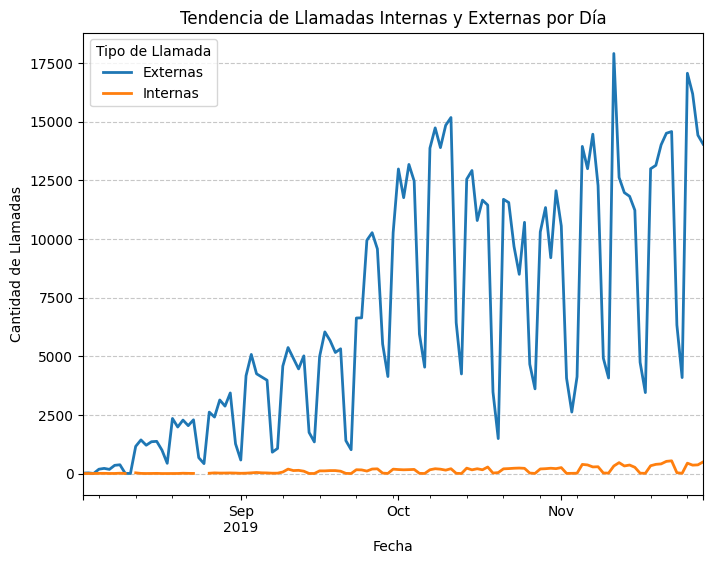

In [19]:
#Se muestra la cantidad de llamadas por fecha y tipo de llamada (interna/externa)

daily_calls_split = telecom.groupby(['date', 'internal'])['calls_count'].sum().unstack()

daily_calls_split.plot(figsize=(8, 6), linewidth=2)
plt.title('Tendencia de Llamadas Internas y Externas por Día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Llamadas')
plt.legend(title='Tipo de Llamada', labels=['Externas', 'Internas'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El análisis del gráfico de la cantidad de llamadas por fecha y tipo de llamada (interna/externa) pone en evidencia un **nivel notablemente bajo de registros antes del mes de octubre**. Esta situación podría deberse a una posible falta de datos completos para las fechas anteriores, lo que sugiere que el conjunto de datos podría no abarcar todo el período de tiempo en estudio. Alternativamente, también es plausible que un evento externo haya ocurrido en o después de octubre, provocando un aumento significativo en la actividad de llamadas a partir de ese momento.

Por otro lado, el nivel de llamadas internas es visiblemente reducido en comparación con las llamadas externas. De hecho, hay algunos días en los que no se registró ninguna llamada interna, lo cual destaca su escasa frecuencia. Este comportamiento podría reflejar una menor necesidad de comunicación interna entre los operadores o, posiblemente, la priorización de la atención hacia llamadas externas.

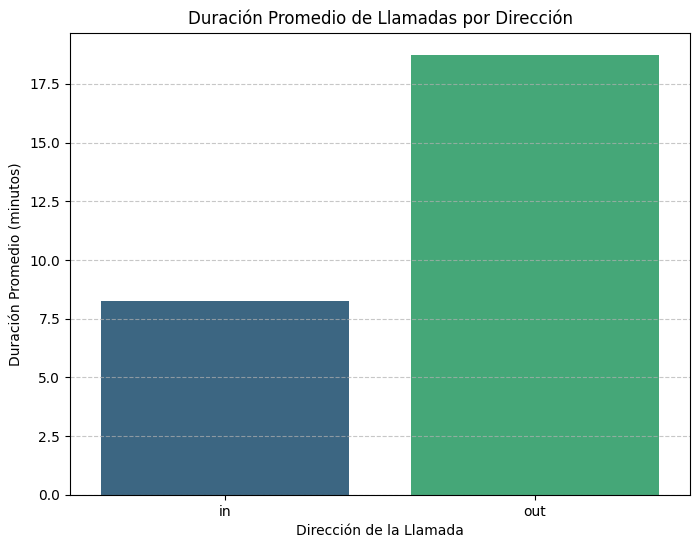

In [20]:
#Se muestra la duración promedio de las llamadas segun su tipo (interna/externa)

avg_call_duration = telecom.groupby('direction')['call_duration'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=avg_call_duration, x='direction', y='call_duration', palette='viridis')
plt.title('Duración Promedio de Llamadas por Dirección')
plt.xlabel('Dirección de la Llamada')
plt.ylabel('Duración Promedio (minutos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Se observa una diferencia notable en la duración promedio de las llamadas según su dirección. En el caso de las llamadas **salientes, la duración promedio supera los 17.5 minutos**, lo que podría reflejar conversaciones más extensas o interacciones más detalladas con los clientes. Por otro lado, las **llamadas entrantes tienen una duración significativamente menor, con un promedio de 7.5 minutos**, lo que sugiere que estas llamadas suelen ser más breves, posiblemente debido a que están orientadas a consultas rápidas o a la resolución de problemas específicos.

Esta diferencia en la duración también podría estar relacionada con el propósito de cada tipo de llamada. Las llamadas salientes, por ejemplo, podrían incluir ventas, negociaciones o seguimientos, que requieren más tiempo, mientras que las entrantes podrían estar limitadas por la urgencia de los clientes o la naturaleza de las consultas. Este contraste destaca la necesidad de ajustar estrategias y recursos según el tipo de interacción para optimizar el desempeño operativo.

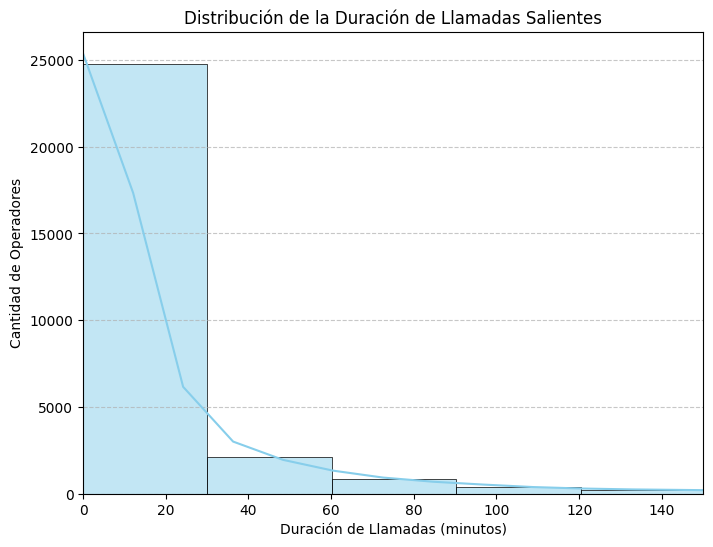

In [21]:
#Se muestra la distribución de la duración de llamadas salientes
outgoing_calls = telecom[telecom['direction'] == 'out']

plt.figure(figsize=(8, 6))
sns.histplot(outgoing_calls['call_duration'], bins=80, kde=True, color='skyblue')

plt.title('Distribución de la Duración de Llamadas Salientes')
plt.xlabel('Duración de Llamadas (minutos)')
plt.ylabel('Cantidad de Operadores')
plt.xlim(0, 150)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En el análisis de la distribución de la duración de las llamadas salientes, se observa que una gran proporción de operadores, **alrededor de 25,000, realizan llamadas que no superan los 30 minutos**, lo que sugiere que estas llamadas suelen ser relativamente breves y podrían estar relacionadas con interacciones más puntuales o de menor complejidad. Esta tendencia es bastante predominante, reflejando un patrón común en la duración de las llamadas realizadas por la mayoría de los operadores.

Por otro lado, se destaca de manera evidente que el número de operadores que llevan a cabo llamadas con una duración superior a los 60 minutos es considerablemente bajo. Este comportamiento puede indicar que las llamadas prolongadas son menos frecuentes o están reservadas para situaciones más complejas o excepcionales, donde se requiere más tiempo para resolver un problema o atender una solicitud. La baja cantidad de operadores que alcanzan este umbral podría señalar una especialización en las tareas, con la mayoría de las interacciones quedando dentro de rangos de tiempo más cortos.

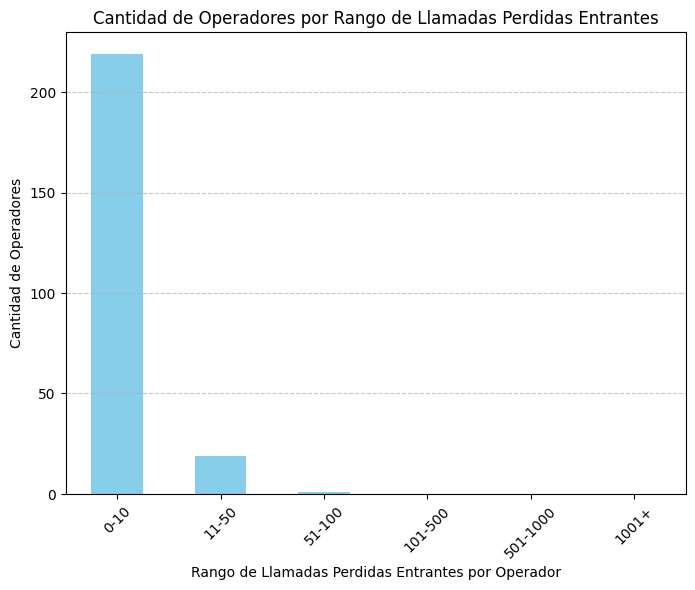

In [22]:
#Se muestra la cantidad de operadores por rango de llamadas perdidas entrantes

#Se filtran las llamadas perdidas entrantes
missed_incoming_calls = telecom[(telecom['is_missed_call']) & (telecom['direction'] == 'in')]

#Se cuentan las llamadas perdidas entrantes por operador
missed_calls_by_operator = missed_incoming_calls.groupby('operator_id')['calls_count'].sum()

#Se crean categorías de operadores basadas en la cantidad de llamadas perdidas entrantes
bins = [0, 10, 50, 100, 500, 1000, 5000]  # Rangos de cantidad de llamadas perdidas
labels = ['0-10', '11-50', '51-100', '101-500', '501-1000', '1001+']  # Etiquetas para las categorías

#Se categorizan los operadores según la cantidad de llamadas perdidas entrantes
missed_calls_by_operator_binned = pd.cut(missed_calls_by_operator, bins=bins, labels=labels)

#Se cuenta la cantidad de operadores en cada categoría
operators_per_category = missed_calls_by_operator_binned.value_counts().sort_index()

#Se grafica la cantidad de operadores por rango de llamadas perdidas entrantes
plt.figure(figsize=(8, 6))
operators_per_category.plot(kind='bar', color='skyblue')

plt.title('Cantidad de Operadores por Rango de Llamadas Perdidas Entrantes')
plt.xlabel('Rango de Llamadas Perdidas Entrantes por Operador')
plt.ylabel('Cantidad de Operadores')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El análisis del gráfico muestra que el rango con la mayor concentración de operadores es el de **0-10 llamadas perdidas entrantes**, el cual incluye a más de 200 operadores. Este grupo representa un desempeño relativamente positivo, ya que mantener un nivel bajo de llamadas perdidas podría considerarse aceptable para la mayoría de los estándares operativos. 

El siguiente rango más significativo es el de **11-50 llamadas perdidas entrantes**, que, aunque agrupa a menos de 50 operadores, se destaca como un volumen notablemente mayor en comparación con las categorías restantes. Esto sugiere que, aunque no es el grupo predominante, aún representa un número considerable de operadores que necesitan atención para reducir este indicador.

En cuanto a los rangos superiores, como el de **51-100 llamadas perdidas entrantes**, su presencia es mucho más reducida, con muy pocos operadores incluidos en esta categoría. Esto es apenas perceptible en el gráfico, lo que indica que, si bien existen operadores con niveles más altos de llamadas perdidas entrantes, estos son una minoría que podría estar afectando de manera significativa la eficiencia general del sistema.

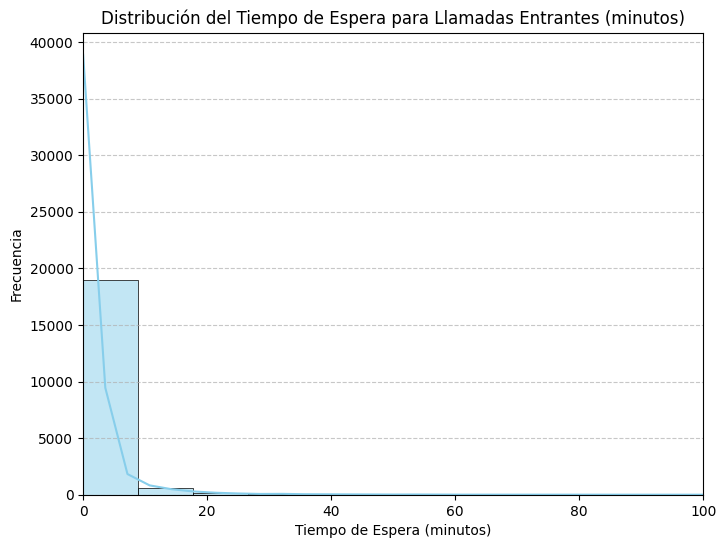

In [23]:
#Se muestra la distribución del tiempo de espera para llamadas entrantes

incoming_calls = telecom[telecom['direction'] == 'in']

plt.figure(figsize=(8, 6))
sns.histplot(incoming_calls['waiting_time'], bins=80, kde=True, color='skyblue')

plt.title('Distribución del Tiempo de Espera para Llamadas Entrantes (minutos)')
plt.xlabel('Tiempo de Espera (minutos)')
plt.ylabel('Frecuencia')
plt.xlim(0, 100)  #Se limita el rango del eje X para mayor claridad
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Al examinar el gráfico de distribución del tiempo de espera para llamdas entrantes (en minutos), se puede observar que una gran **mayoría de las llamadas, alrededor de 40,000, tienen un tiempo de espera de menos de 10 minutos**, lo que indica que la mayor parte de los clientes experimentan tiempos de espera relativamente cortos. Sin embargo, hay una fracción significativa de llamadas cuyo tiempo de espera oscila entre los 10 y 20 minutos, aunque esta cantidad disminuye de manera considerable conforme el tiempo de espera aumenta. A pesar de esta disminución, es relevante notar que todavía existen algunas llamadas que presentan tiempos de espera mucho más largos, lo que sugiere que, aunque la mayoría de las interacciones son resueltas rápidamente, un número menor de llamadas se encuentran con retrasos más extensos, lo que podría ser indicativo de cuellos de botella en el sistema o problemas operativos que merecen atención.

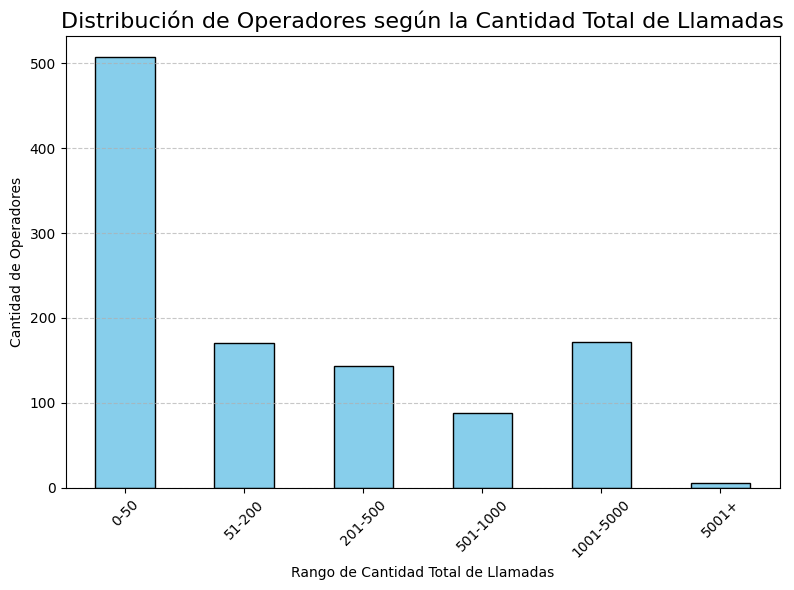

In [24]:
#Se muestra la distribución de operadores por rango de cantidad de llamadas

#Se calcula la cantidad total de llamadas por operador
total_calls_by_operator = telecom.groupby('operator_id')['calls_count'].sum()

#Se crean categorías de operadores basadas en la cantidad total de llamadas
bins = [0, 50, 200, 500, 1000, 5000, 10000]  # Rangos de cantidad de llamadas
labels = ['0-50', '51-200', '201-500', '501-1000', '1001-5000', '5001+']  # Etiquetas para las categorías

#Se categorizan los operadores según la cantidad total de llamadas
calls_binned = pd.cut(total_calls_by_operator, bins=bins, labels=labels)

#Se cuenta el número de operadores en cada categoría
operator_count_by_calls = calls_binned.value_counts().sort_index()

#Se grafica la distribución de operadores por rango de cantidad de llamadas
plt.figure(figsize=(8, 6))
operator_count_by_calls.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Distribución de Operadores según la Cantidad Total de Llamadas', fontsize=16)
plt.xlabel('Rango de Cantidad Total de Llamadas')
plt.ylabel('Cantidad de Operadores')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Al analizar la distribucion de operadores segun la cantidad total de llamadas se revela que **la mayoría de los operadores se concentran en el rango más bajo, con hasta 50 llamadas registradas**. Este grupo representa un número considerablemente elevado en comparación con las demás categorias pues supera ligeramente los 500 operadores. Las categorías que abarcan entre 51 y 500 llamadas muestran una disminución en la cantidad de operadores, situándose entre 100 y 200 operadores por rango.

En el caso de los operadores que registran **entre 501 y 1000 llamadas, su representación es aún menor, con menos de 100 operadores en esta categoría**. Sin embargo, en el rango de 1001 a 5000 llamadas, se observa un ligero repunte en comparación con las categorías anteriores, aunque sigue siendo un grupo moderado que no supera los 200 operadores.

Por último, la categoría de **más de 5001 llamadas cuenta con la menor cantidad de operadores**, destacando como un grupo reducido. Este hallazgo coincide con las observaciones previas que indicaban la presencia de un pequeño número de operadores con volúmenes excepcionalmente altos de llamadas, evidenciando un comportamiento atípico en comparación con la mayoría.

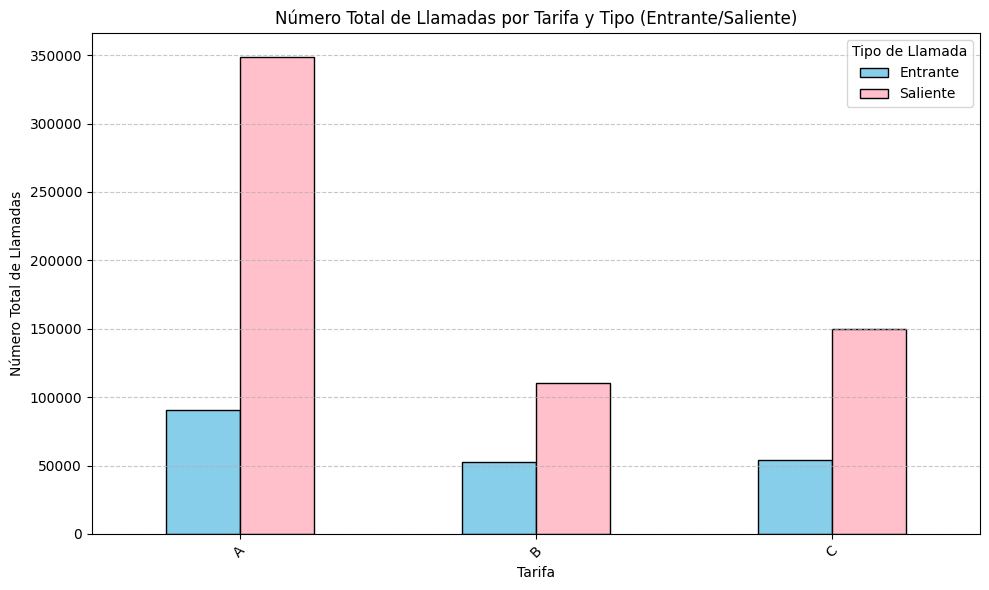

In [25]:
# Se muestran las llamadas por tipo de tarifa y tipo (entrante/saliente)

# Se agrupan las llamadas por tipo de tarifa y tipo (entrante/saliente)
calls_by_tariff_and_direction = telecom.groupby(['tariff_plan', 'direction'])['calls_count'].sum().reset_index()

# Se pivotea la tabla para tener columnas separadas por tipo (entrante/saliente)
calls_by_tariff_pivot = calls_by_tariff_and_direction.pivot(index='tariff_plan', columns='direction', values='calls_count').fillna(0)

# Se grafica un gráfico de barras agrupadas
calls_by_tariff_pivot.plot(
    kind='bar', 
    figsize=(10, 6), 
    color=['skyblue', 'pink'], 
    edgecolor='black'
)

plt.title('Número Total de Llamadas por Tarifa y Tipo (Entrante/Saliente)')
plt.xlabel('Tarifa')
plt.ylabel('Número Total de Llamadas')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Llamada', labels=['Entrante', 'Saliente'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A partir del análisis del gráfico, podemos observar que el plan **A** registra el mayor volumen de llamadas en comparación con las demás tarifas, consolidándose como la opción más utilizada. Este plan acumula aproximadamente 350,000 llamadas salientes, lo que sugiere que es altamente promocionado por los operadores, probablemente debido a su relación costo-beneficio o a campañas específicas dirigidas hacia su contratación. Además, el plan **A** presenta un alto número de llamadas entrantes, alcanzando casi los 100,000 registros, lo que refuerza la idea de su amplia popularidad entre los usuarios.

Por otro lado, el plan **B** se posiciona como el de menor volumen de llamadas, con un total ligeramente superior a las 100,000 llamadas salientes y cerca de 50,000 llamadas entrantes. Esto podría indicar una menor promoción o características menos atractivas para los usuarios en comparación con las otras tarifas.

El plan **C**, aunque menos popular que el plan **A**, ocupa el segundo lugar en volumen total de llamadas. Este plan alcanza alrededor de 150,000 llamadas salientes y 50,000 llamadas entrantes, lo que sugiere que tiene una base de usuarios más moderada, posiblemente orientada hacia un segmento específico del mercado.

En general, esta distribución destaca la amplia aceptación del plan **A**, mientras que los planes **B** y **C** reflejan niveles de uso significativamente menores, lo que podría ser un indicio de diferentes estrategias comerciales o preferencias de los usuarios.

# Planteamiento y Prueba de Hipótesis

Con base en el objetivo, las hipótesis relevantes que se pueden plantear son las siguientes:

* H1: Los operadores con más de un porcentaje específico de llamadas perdidas tienen un desempeño ineficaz.
* H2: Un tiempo promedio de espera prolongado está correlacionado con un mayor porcentaje de llamadas perdidas.
* H3: Los operadores responsables de llamadas salientes con un bajo número de estas son menos eficaces que otros con un rol similar.
* H4: El tipo de plan tarifario del cliente influye en la duración promedio de las llamadas, tanto entrantes como salientes.

## H1: Los operadores con más de un porcentaje específico de llamadas perdidas tienen un desempeño ineficaz.

In [26]:
#Se contabilizan los datos necesarios

#Total de llamadas por operador
total_calls_by_operator = telecom.groupby('operator_id')['calls_count'].sum()

#Total de llamadas perdidas por operador
missed_calls_by_operator = telecom[telecom['is_missed_call']].groupby('operator_id')['calls_count'].sum()

#Porcentaje de llamadas perdidas
missed_calls_percentage = (missed_calls_by_operator / total_calls_by_operator) * 100
missed_calls_percentage = missed_calls_percentage.fillna(0)  # Rellenar valores NaN con 0

#Se define el humbral
threshold = 20  # Porcentaje de llamadas perdidas
inefficient_operators = missed_calls_percentage[missed_calls_percentage > threshold]

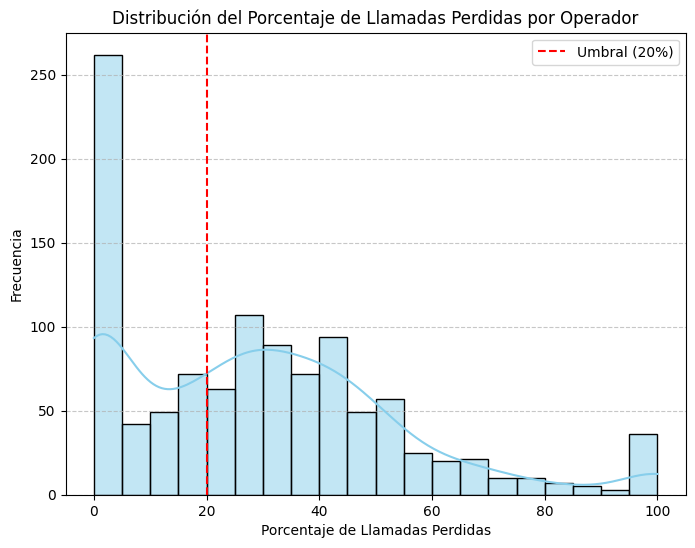

In [27]:
# Se visualiza la distribución del porcentaje de llamadas perdidas
plt.figure(figsize=(8, 6))
sns.histplot(missed_calls_percentage, bins=20, kde=True, color='skyblue')
plt.title('Distribución del Porcentaje de Llamadas Perdidas por Operador')
plt.xlabel('Porcentaje de Llamadas Perdidas')
plt.ylabel('Frecuencia')
plt.axvline(threshold, color='red', linestyle='--', label=f'Umbral ({threshold}%)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

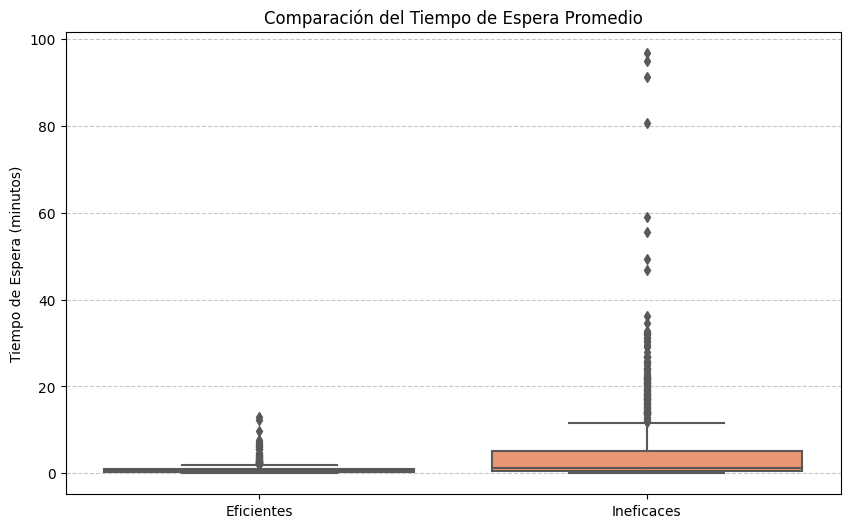

In [28]:
#Se compara el desempeño de los operadores

#Se establecen las metricas de desempeño por operador
performance_metrics = telecom.groupby('operator_id').agg(
    avg_waiting_time=('waiting_time', 'mean'),
    avg_call_duration=('call_duration', 'mean')
)

#Se agrega la columna de porcentaje de llamadas perdidas
performance_metrics['missed_calls_percentage'] = missed_calls_percentage

#Se dividen en grupos
efficient = performance_metrics[performance_metrics['missed_calls_percentage'] <= threshold]
inefficient = performance_metrics[performance_metrics['missed_calls_percentage'] > threshold]

#Se visualizan las métricas por grupo
plt.figure(figsize=(10, 6))
sns.boxplot(data=[efficient['avg_waiting_time'], inefficient['avg_waiting_time']], palette='Set2')
plt.xticks([0, 1], ['Eficientes', 'Ineficaces'])
plt.title('Comparación del Tiempo de Espera Promedio')
plt.ylabel('Tiempo de Espera (minutos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
#Se realiza la validación estadística

#Se aplica una prueba t para el tiempo de espera promedio
t_stat, p_value = ttest_ind(efficient['avg_waiting_time'], inefficient['avg_waiting_time'], nan_policy='omit')

print(f"T-statistic: {t_stat}, P-value: {p_value}")
if p_value < 0.05:
    print("Hay una diferencia significativa en el tiempo de espera promedio entre operadores eficientes e ineficaces.")
else:
    print("No hay una diferencia significativa en el tiempo de espera promedio.")


T-statistic: -8.582364835869587, P-value: 3.155690527597575e-17
Hay una diferencia significativa en el tiempo de espera promedio entre operadores eficientes e ineficaces.


## H2: Un tiempo promedio de espera prolongado está correlacionado con un mayor porcentaje de llamadas perdidas.

In [30]:
#Se realizan los calculos necesarios

#Se calcula el tiempo de espera promedio por operador
average_waiting_time_by_operator = telecom.groupby('operator_id')['waiting_time'].mean()

#Se calcula el porcentaje de llamadas perdidas por operador
total_calls_by_operator = telecom.groupby('operator_id')['calls_count'].sum()
missed_calls_by_operator = telecom[telecom['is_missed_call']].groupby('operator_id')['calls_count'].sum()
missed_calls_percentage = (missed_calls_by_operator / total_calls_by_operator) * 100
missed_calls_percentage = missed_calls_percentage.fillna(0)  #Se rellenan los valores NaN con 0

#Se combinan las métricas en un solo DataFrame
correlation_data = pd.DataFrame({
    'avg_waiting_time': average_waiting_time_by_operator,
    'missed_calls_percentage': missed_calls_percentage
}).dropna()

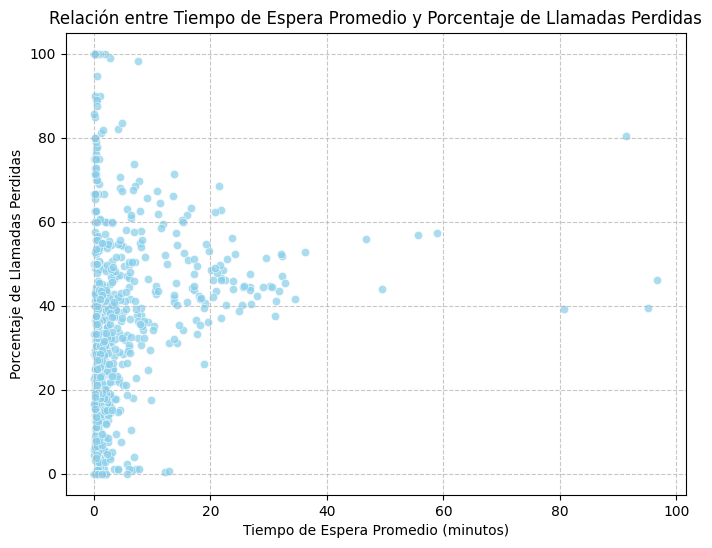

In [31]:
#Se visualiza la relación
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=correlation_data,
    x='avg_waiting_time',
    y='missed_calls_percentage',
    color='skyblue',
    alpha=0.7
)
plt.title('Relación entre Tiempo de Espera Promedio y Porcentaje de Llamadas Perdidas')
plt.xlabel('Tiempo de Espera Promedio (minutos)')
plt.ylabel('Porcentaje de Llamadas Perdidas')
plt.grid(alpha=0.7, linestyle='--')
plt.show()

In [32]:
#Se analiza la correlación

pearson_corr, pearson_pval = pearsonr(correlation_data['avg_waiting_time'], correlation_data['missed_calls_percentage'])
spearman_corr, spearman_pval = spearmanr(correlation_data['avg_waiting_time'], correlation_data['missed_calls_percentage'])

print(f"Coeficiente de correlación de Pearson: {pearson_corr:.2f}, P-valor: {pearson_pval:.4f}")
print(f"Coeficiente de correlación de Spearman: {spearman_corr:.2f}, P-valor: {spearman_pval:.4f}")

if pearson_pval < 0.05:
    print("La correlación de Pearson indica una relación estadísticamente significativa entre el tiempo de espera promedio y el porcentaje de llamadas perdidas.")
else:
    print("No se encontró una correlación significativa entre estas variables según Pearson.")

if spearman_pval < 0.05:
    print("La correlación de Spearman indica una relación estadísticamente significativa entre el tiempo de espera promedio y el porcentaje de llamadas perdidas.")
else:
    print("No se encontró una correlación significativa entre estas variables según Spearman.")

Coeficiente de correlación de Pearson: 0.22, P-valor: 0.0000
Coeficiente de correlación de Spearman: 0.31, P-valor: 0.0000
La correlación de Pearson indica una relación estadísticamente significativa entre el tiempo de espera promedio y el porcentaje de llamadas perdidas.
La correlación de Spearman indica una relación estadísticamente significativa entre el tiempo de espera promedio y el porcentaje de llamadas perdidas.


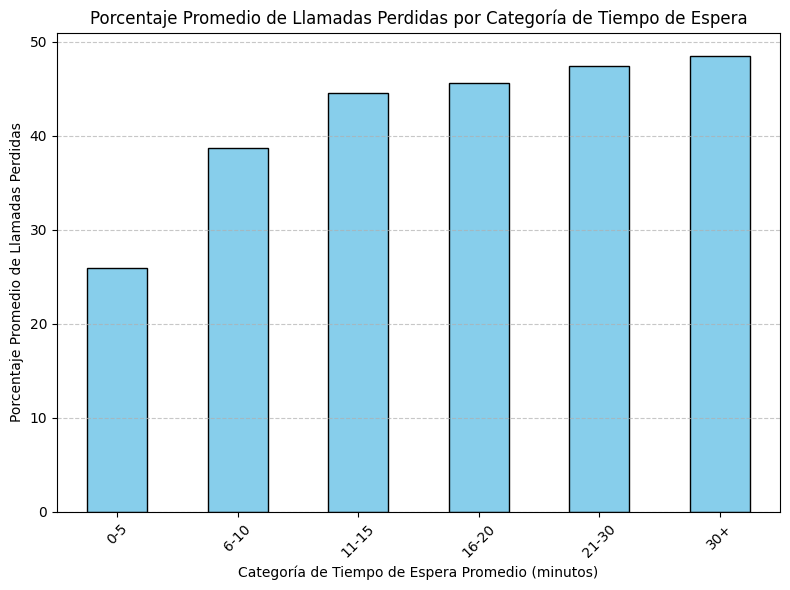

In [33]:
#Se muestra la relación categorizada

#Se crean las categorías de tiempo de espera promedio
bins = [0, 5, 10, 15, 20, 30, correlation_data['avg_waiting_time'].max()]
labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '30+']
correlation_data['waiting_time_category'] = pd.cut(correlation_data['avg_waiting_time'], bins=bins, labels=labels)

#Se calcula el promedio de porcentaje de llamadas perdidas por categoría
grouped_data = correlation_data.groupby('waiting_time_category')['missed_calls_percentage'].mean()

# Se grafica la relación categorizada
plt.figure(figsize=(8, 6))
grouped_data.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porcentaje Promedio de Llamadas Perdidas por Categoría de Tiempo de Espera')
plt.xlabel('Categoría de Tiempo de Espera Promedio (minutos)')
plt.ylabel('Porcentaje Promedio de Llamadas Perdidas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## H3: Los operadores responsables de llamadas salientes con un bajo número de estas son menos eficaces que otros con un rol similar.

In [34]:
#Se identifican los operadores "menos eficaces"

#Se filtran las llamadas salientes
outgoing_calls = telecom[telecom['direction'] == 'out']

#Se calcula la cantidad total de llamadas salientes por operador
outgoing_calls_by_operator = outgoing_calls.groupby('operator_id')['calls_count'].sum()

#Se define un umbral como el percentil 25 para identificar operadores con bajo volumen de llamadas salientes
low_call_threshold = outgoing_calls_by_operator.quantile(0.25)

#Se clasifican los operadores en dos grupos: "bajo rendimiento" y "alto rendimiento"
operator_efficiency = pd.DataFrame({
    'total_outgoing_calls': outgoing_calls_by_operator,
    'efficiency_group': ['Low' if calls <= low_call_threshold else 'High' for calls in outgoing_calls_by_operator]
}).reset_index()

In [35]:
#Se comparan métricas de rendimiento entre los dos grupos

#Se agregan métricas relevantes: porcentaje de llamadas perdidas y tiempo promedio de espera
missed_calls_percentage = outgoing_calls[outgoing_calls['is_missed_call']].groupby('operator_id')['calls_count'].sum() / outgoing_calls_by_operator * 100
average_waiting_time = outgoing_calls.groupby('operator_id')['waiting_time'].mean()

operator_efficiency = operator_efficiency.merge(
    missed_calls_percentage.rename('missed_calls_percentage'), 
    on='operator_id', 
    how='left'
).merge(
    average_waiting_time.rename('average_waiting_time'), 
    on='operator_id', 
    how='left'
).fillna(0)

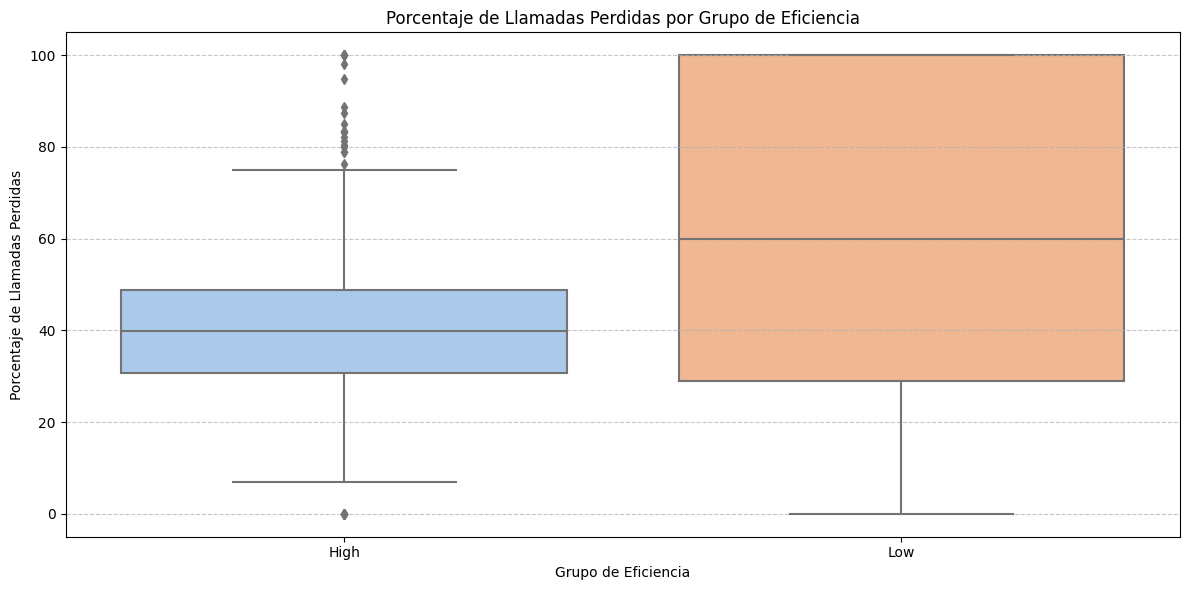

In [36]:
#Se visualiza la comparación entre los grupos según el número de llamadas perdidas

plt.figure(figsize=(12, 6))
sns.boxplot(data=operator_efficiency, x='efficiency_group', y='missed_calls_percentage', palette='pastel')
plt.title('Porcentaje de Llamadas Perdidas por Grupo de Eficiencia')
plt.xlabel('Grupo de Eficiencia')
plt.ylabel('Porcentaje de Llamadas Perdidas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

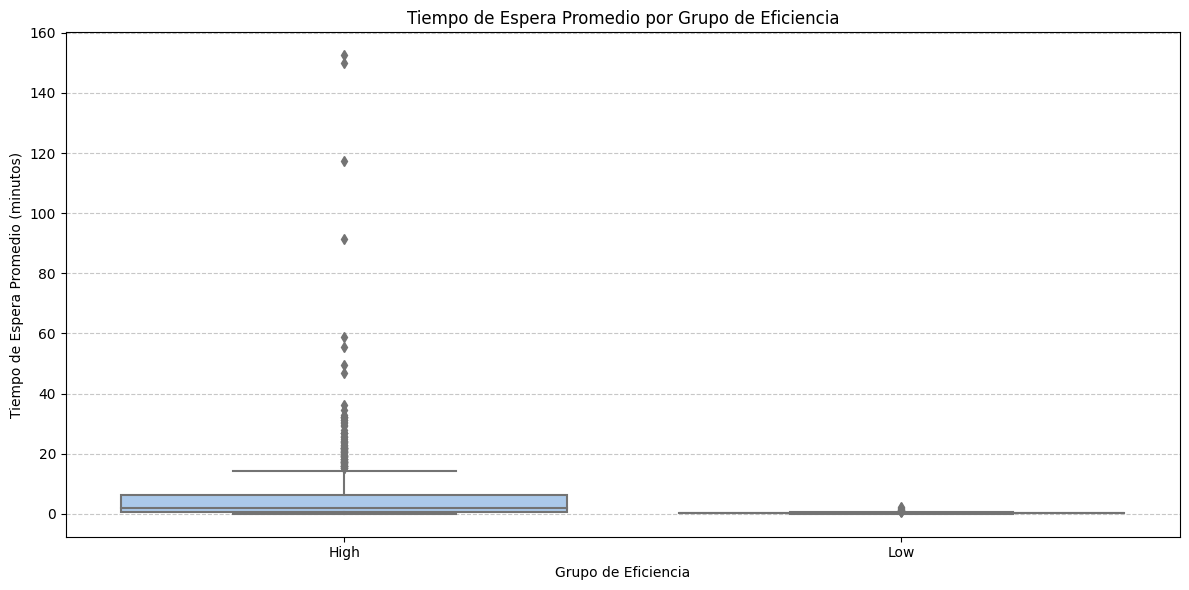

In [37]:
#Se visualiza la comparación entre los grupos según el tiempo de espera

plt.figure(figsize=(12, 6))
sns.boxplot(data=operator_efficiency, x='efficiency_group', y='average_waiting_time', palette='pastel')
plt.title('Tiempo de Espera Promedio por Grupo de Eficiencia')
plt.xlabel('Grupo de Eficiencia')
plt.ylabel('Tiempo de Espera Promedio (minutos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [38]:
#Se aplican pruebas estadística para comparar el porcentaje de llamadas perdidas entre los dos grupos
low_efficiency_missed = operator_efficiency[operator_efficiency['efficiency_group'] == 'Low']['missed_calls_percentage']
high_efficiency_missed = operator_efficiency[operator_efficiency['efficiency_group'] == 'High']['missed_calls_percentage']

stat, p_value = mannwhitneyu(low_efficiency_missed, high_efficiency_missed, alternative='two-sided')
print(f"Prueba Mann-Whitney para porcentaje de llamadas perdidas:\nEstadístico U: {stat:.2f}, P-valor: {p_value:.4f}")
if p_value < 0.05:
    print("Existe una diferencia estadísticamente significativa en el porcentaje de llamadas perdidas entre los dos grupos.")

Prueba Mann-Whitney para porcentaje de llamadas perdidas:
Estadístico U: 95973.50, P-valor: 0.0000
Existe una diferencia estadísticamente significativa en el porcentaje de llamadas perdidas entre los dos grupos.


In [39]:
#Se aplican pruebas estadística para comparar el tiempo promedio de espera entre los dos grupos
low_efficiency_waiting = operator_efficiency[operator_efficiency['efficiency_group'] == 'Low']['average_waiting_time']
high_efficiency_waiting = operator_efficiency[operator_efficiency['efficiency_group'] == 'High']['average_waiting_time']

stat, p_value = mannwhitneyu(low_efficiency_waiting, high_efficiency_waiting, alternative='two-sided')
print(f"Prueba Mann-Whitney para tiempo de espera promedio:\nEstadístico U: {stat:.2f}, P-valor: {p_value:.4f}")
if p_value < 0.05:
    print("Existe una diferencia estadísticamente significativa en el tiempo de espera promedio entre los dos grupos.")
else:
    print("No se encontró una diferencia estadísticamente significativa en el tiempo de espera promedio entre los dos grupos.")


Prueba Mann-Whitney para tiempo de espera promedio:
Estadístico U: 13806.50, P-valor: 0.0000
Existe una diferencia estadísticamente significativa en el tiempo de espera promedio entre los dos grupos.


## H4: El tipo de plan tarifario del cliente influye en la duración promedio de las llamadas, tanto entrantes como salientes.

In [40]:
#Se filtran las llamadas entrantes y salientes
incoming_calls = telecom[telecom['direction'] == 'in']
outgoing_calls = telecom[telecom['direction'] == 'out']

#Se calcula la duración promedio de llamadas por tipo de plan tarifario
average_duration_by_tariff_in = incoming_calls.groupby('tariff_plan')['call_duration'].mean().rename('avg_duration_in')
average_duration_by_tariff_out = outgoing_calls.groupby('tariff_plan')['call_duration'].mean().rename('avg_duration_out')

#Se combinan datos de duración promedio en un solo DataFrame
average_duration_by_tariff = pd.concat([average_duration_by_tariff_in, average_duration_by_tariff_out], axis=1).reset_index()

<Figure size 1200x600 with 0 Axes>

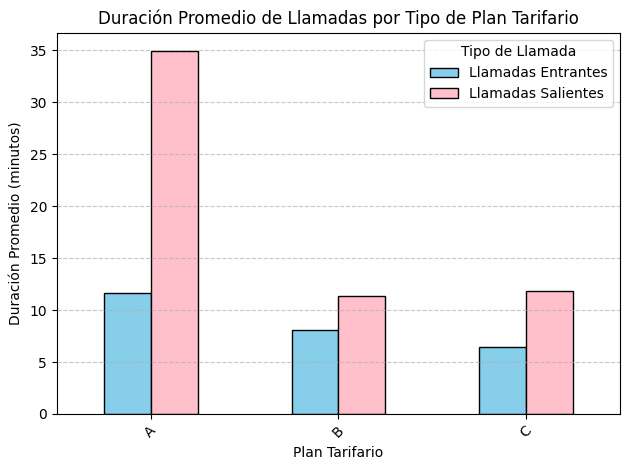

In [41]:
#Se visualiza la duración promedio por tipo de plan
plt.figure(figsize=(12, 6))
average_duration_by_tariff.plot(
    x='tariff_plan', 
    kind='bar', 
    stacked=False, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
)
plt.title('Duración Promedio de Llamadas por Tipo de Plan Tarifario')
plt.xlabel('Plan Tarifario')
plt.ylabel('Duración Promedio (minutos)')
plt.xticks(rotation=45)
plt.legend(['Llamadas Entrantes', 'Llamadas Salientes'], title='Tipo de Llamada')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
#Se aplican pruebas estadísticas para verificar la influencia del plan tarifario

#ANOVA para duración de llamadas entrantes
groups_in = [incoming_calls[incoming_calls['tariff_plan'] == plan]['call_duration'] for plan in incoming_calls['tariff_plan'].unique()]
stat_in, p_value_in = f_oneway(*groups_in)

#ANOVA para duración de llamadas salientes
groups_out = [outgoing_calls[outgoing_calls['tariff_plan'] == plan]['call_duration'] for plan in outgoing_calls['tariff_plan'].unique()]
stat_out, p_value_out = f_oneway(*groups_out)

# Resultados de las pruebas estadísticas
print(f"ANOVA para duración promedio de llamadas entrantes:\nEstadístico F: {stat_in:.2f}, P-valor: {p_value_in:.4f}")
if p_value_in < 0.05:
    print("La duración promedio de llamadas entrantes varía significativamente según el tipo de plan tarifario.")
else:
    print("No se encontró una variación significativa en la duración promedio de llamadas entrantes según el tipo de plan tarifario.")

print(f"\nANOVA para duración promedio de llamadas salientes:\nEstadístico F: {stat_out:.2f}, P-valor: {p_value_out:.4f}")
if p_value_out < 0.05:
    print("La duración promedio de llamadas salientes varía significativamente según el tipo de plan tarifario.")
else:
    print("No se encontró una variación significativa en la duración promedio de llamadas salientes según el tipo de plan tarifario.")


ANOVA para duración promedio de llamadas entrantes:
Estadístico F: 82.50, P-valor: 0.0000
La duración promedio de llamadas entrantes varía significativamente según el tipo de plan tarifario.

ANOVA para duración promedio de llamadas salientes:
Estadístico F: 270.18, P-valor: 0.0000
La duración promedio de llamadas salientes varía significativamente según el tipo de plan tarifario.


[Volver a Contenidos](#back)

# Conclusiones y Recomendaciones

El análisis de datos realizado en el presente proyecto permite identificar patrones clave que influyen en la eficacia operativa de los servicios de telefonía virtual de CallMeMaybe. Las observaciones y resultados estadísticos obtenidos destacan áreas críticas para optimizar el desempeño de los operadores y mejorar la experiencia del cliente.

**Hallazgos Clave**

**1. Ineficiencia Operativa:** Un pequeño grupo de operadores registra un volumen excepcionalmente alto de llamadas, mientras que la mayoría mantiene niveles significativamente bajos.
Operadores con tiempos de espera prolongados tienden a presentar un mayor porcentaje de llamadas perdidas, afectando la percepción de calidad del servicio.

**2. Duración de Llamadas:** Las llamadas salientes presentan una duración promedio mayor (17.5 minutos) en comparación con las entrantes (7.5 minutos), lo que podría reflejar diferencias en los objetivos y necesidades de cada tipo de interacción.
Los planes tarifarios influyen significativamente en la duración promedio de las llamadas, tanto entrantes como salientes.

**3. Distribución de Llamadas por Plan Tarifario:** El Plan A registra la mayor cantidad de llamadas, tanto entrantes como salientes, consolidándose como la opción más utilizada.
Los planes B y C muestran volúmenes de llamadas considerablemente menores, lo que podría estar relacionado con estrategias comerciales o características específicas de estos planes.

**4. Relación entre Tiempos de Espera y Llamadas Perdidas:** Se identificó una correlación significativa entre el tiempo promedio de espera y el porcentaje de llamadas perdidas, evidenciando que tiempos de espera más largos afectan negativamente la retención de clientes.

**5. Distribución de Operadores y Llamadas:** La mayoría de los operadores realiza menos de 50 llamadas, lo que sugiere una subutilización de recursos.
Un número reducido de operadores concentra un volumen desproporcionadamente alto de llamadas, lo que podría estar generando cuellos de botella.

**Recomendaciones**

**1. Gestión de Operadores:** Implementar una redistribución de las cargas de trabajo para equilibrar la cantidad de llamadas entre operadores y reducir cuellos de botella.
Desarrollar programas de capacitación dirigidos a mejorar la eficiencia de los operadores con bajo desempeño, priorizando aquellos con altas tasas de llamadas perdidas y tiempos de espera prolongados.

**2. Optimización de Tiempos de Espera:** Automatizar procesos iniciales en las llamadas (e.g., sistemas IVR más eficientes) para reducir tiempos de espera en interacciones rutinarias.
Monitorear en tiempo real los tiempos de espera y establecer alertas para atender picos inusuales.

**3. Revisión de Planes Tarifarios:** Evaluar la rentabilidad y la percepción del cliente sobre los planes B y C. En caso necesario, ajustar precios o beneficios para aumentar su competitividad.
Diseñar campañas promocionales específicas para los planes menos populares, destacando sus ventajas frente a la competencia.

**4. Priorización de Llamadas:** Establecer criterios de priorización para llamadas entrantes según el tiempo de espera acumulado y la naturaleza de la consulta, garantizando una atención más rápida para casos urgentes.

**5. Seguimiento y Evaluación Continua:** Realizar análisis periódicos de las métricas clave para identificar y corregir nuevas ineficiencias de manera proactiva.
Invertir en tecnología de análisis predictivo para prever fluctuaciones en la demanda y asignar recursos de forma dinámica.


**Impacto Esperado**

La implementación de estas recomendaciones puede contribuir a:

* Reducir las tasas de llamadas perdidas y mejorar la satisfacción del cliente.
* Incrementar la eficiencia operativa al optimizar la distribución del trabajo entre los operadores.
* Fortalecer la posición competitiva de CallMeMaybe mediante un servicio más ágil y adaptado a las necesidades de los clientes.
* Con estos hallazgos y estrategias, la empresa está mejor posicionada para abordar sus retos operativos y avanzar hacia una gestión de servicios más eficiente y orientada al cliente.

[Volver a Contenidos](#back)